In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.regularizers import l1_l2
from keras.optimizers import Adam, RMSprop, SGD
from keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE
import optuna
from sklearn.metrics import accuracy_score

In [2]:
df=pd.read_csv(r"C:\Users\HP\Downloads\archive (1)\creditcard.csv")

In [3]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [7]:
df.duplicated().sum()

np.int64(1081)

In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
df.head(1)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0


In [12]:
df["Time"] = pd.to_datetime(df["Time"])

df["Hour"] = df["Time"].dt.hour
df["Day"] = df["Time"].dt.day
df["Month"] = df["Time"].dt.month

In [13]:
X = df.drop(columns=["Class"])

In [14]:
X = df.drop(columns=["Class", "Time"])
y = df["Class"]

In [15]:
X_train_full , X_test,y_train_full,y_test = train_test_split(X,y,test_size=0.2,random_state=21,stratify=y)

In [16]:
X_train,X_val,y_train,y_val = train_test_split(X_train_full,y_train_full,test_size=0.2,random_state=21,stratify=y_train_full)

In [17]:
num_cols = X.select_dtypes(exclude = "object").columns
cat_cols = X.select_dtypes(include = "object").columns

In [18]:
preprocessor = ColumnTransformer([("Scaling",MinMaxScaler(),num_cols),
                                  ("Encoding",OneHotEncoder(drop = "first",handle_unknown="ignore"),cat_cols)],
                                 remainder = "drop")

In [19]:
X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

In [20]:
model = Sequential([Input(shape=(X_train_t.shape[1],)),
                    Dense(32,activation="relu"),
                    Dense(64,activation="relu"),
                    Dense(1,activation="sigmoid")])

In [21]:
model.compile(optimizer="Adam",loss = "binary_crossentropy",metrics = ["accuracy"])

In [22]:
early = EarlyStopping(monitor = "val_loss",patience = 5 , restore_best_weights=True)

In [23]:
model.fit(X_train_t,y_train,
          epochs = 50,
          validation_data=(X_val_t,y_val),
          batch_size=256,
          callbacks=[early],
          verbose = 2)

Epoch 1/50
713/713 - 3s - 4ms/step - accuracy: 0.9956 - loss: 0.0241 - val_accuracy: 0.9985 - val_loss: 0.0067
Epoch 2/50
713/713 - 1s - 2ms/step - accuracy: 0.9988 - loss: 0.0053 - val_accuracy: 0.9991 - val_loss: 0.0049
Epoch 3/50
713/713 - 1s - 2ms/step - accuracy: 0.9991 - loss: 0.0043 - val_accuracy: 0.9992 - val_loss: 0.0044
Epoch 4/50
713/713 - 1s - 2ms/step - accuracy: 0.9992 - loss: 0.0040 - val_accuracy: 0.9993 - val_loss: 0.0041
Epoch 5/50
713/713 - 1s - 2ms/step - accuracy: 0.9993 - loss: 0.0038 - val_accuracy: 0.9993 - val_loss: 0.0040
Epoch 6/50
713/713 - 1s - 2ms/step - accuracy: 0.9993 - loss: 0.0036 - val_accuracy: 0.9993 - val_loss: 0.0039
Epoch 7/50
713/713 - 1s - 2ms/step - accuracy: 0.9993 - loss: 0.0035 - val_accuracy: 0.9993 - val_loss: 0.0041
Epoch 8/50
713/713 - 1s - 2ms/step - accuracy: 0.9993 - loss: 0.0034 - val_accuracy: 0.9994 - val_loss: 0.0038
Epoch 9/50
713/713 - 1s - 2ms/step - accuracy: 0.9994 - loss: 0.0034 - val_accuracy: 0.9993 - val_loss: 0.0047
E

In [24]:
y_pred = np.where(model.predict(X_test_t)>0.5,1,0)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 888us/step


In [25]:
accuracy_score(y_pred,y_test)

0.999385555282469

In [26]:
smote = SMOTE()
X_train_res,y_train_res = smote.fit_resample(X_train_t,y_train)

In [27]:
def objective(trial):
    lr_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    n_layers = trial.suggest_int('n_layers', 1, 4)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])
    activation = trial.suggest_categorical('activation', ['tanh', 'relu'])
    batch_size1 = trial.suggest_categorical('batch_size', [32, 64, 128, 256, 512])

    model = Sequential()
    model.add(Input(shape=(X_train_res.shape[1],)))
    for i in range(n_layers):
        units = trial.suggest_int(f'units{i}', 8, 96)
        dropout = trial.suggest_float(f'dropout{i}', 0.0, 0.5)
        reg = trial.suggest_float(f'reg{i}', 1e-5, 1e-2, log=True)
        model.add(Dense(units, activation=activation, kernel_regularizer=l1_l2(l1=reg, l2=reg)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))

    opt_map = {
        'Adam': Adam(learning_rate=lr_rate),
        'RMSprop': RMSprop(learning_rate=lr_rate),
        'SGD': SGD(learning_rate=lr_rate)
    }
    model.compile(optimizer=opt_map[optimizer_name], loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.Recall(name='recall')])

    es = EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train_res, y_train_res,
        epochs=30, batch_size=batch_size1,
        validation_data=(X_val_t, y_val),   # validation set, NOT test
        callbacks=[es], verbose=0
    )
    return max(history.history['val_recall'])

In [28]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=21))
study.optimize(objective, n_trials=5, show_progress_bar=True)  

[I 2026-06-29 23:23:26,881] A new study created in memory with name: no-name-7b0b2581-9305-48ae-8fa8-fce5d6167d0c


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-06-29 23:23:49,357] Trial 0 finished with value: 0.8481012582778931 and parameters: {'learning_rate': 0.0001251554487151282, 'n_layers': 2, 'optimizer': 'Adam', 'activation': 'relu', 'batch_size': 512, 'units0': 19, 'dropout0': 0.08906233077974918, 'reg0': 0.00030746001885481724, 'units1': 84, 'dropout1': 0.37947191775605715, 'reg1': 0.008155589837765905}. Best is trial 0 with value: 0.8481012582778931.
[I 2026-06-29 23:27:09,358] Trial 1 finished with value: 0.9873417615890503 and parameters: {'learning_rate': 0.00330069279804087, 'n_layers': 2, 'optimizer': 'RMSprop', 'activation': 'relu', 'batch_size': 32, 'units0': 37, 'dropout0': 0.23007016689648802, 'reg0': 0.0004296403664910425, 'units1': 27, 'dropout1': 0.39993416346948824, 'reg1': 0.001513747182776292}. Best is trial 1 with value: 0.9873417615890503.
[I 2026-06-29 23:28:14,358] Trial 2 finished with value: 1.0 and parameters: {'learning_rate': 0.004995574347086988, 'n_layers': 2, 'optimizer': 'RMSprop', 'activation': '

In [29]:
study.best_params

{'learning_rate': 0.004995574347086988,
 'n_layers': 2,
 'optimizer': 'RMSprop',
 'activation': 'relu',
 'batch_size': 64,
 'units0': 78,
 'dropout0': 0.4438277186036015,
 'reg0': 0.00124905731421375,
 'units1': 48,
 'dropout1': 0.15295758239442775,
 'reg1': 0.0028857135238802138}

In [30]:
model  = Sequential()

# Input Layer 
model.add(Input(shape=(X_train_res.shape[1],)))

# 1st hidden Layer 

model.add(Dense(37,activation='relu',kernel_initializer='he_normal',kernel_regularizer=l1_l2(l1=0.00124905731421375,l2 =0.00124905731421375 )))
model.add(BatchNormalization())
model.add(Dropout(0.4438277186036015))

# 2nd layer 

model.add(Dense(27,activation='relu',kernel_initializer='he_normal',kernel_regularizer=l1_l2(l1=0.0028857135238802138,l2 =0.0028857135238802138 )))
model.add(BatchNormalization())
model.add(Dropout(0.15295758239442775))

# Output layer 

model.add(Dense(1,activation='sigmoid',kernel_initializer="glorot_uniform"))

In [31]:
model.compile(optimizer=RMSprop(learning_rate=0.004995574347086988), loss='binary_crossentropy',
                  metrics=["accuracy",tf.keras.metrics.Recall(name='recall')])

In [32]:
es = EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True)

In [33]:
history = model.fit(
        X_train_res, y_train_res,
        epochs=30, batch_size=32,
        validation_data=(X_val_t, y_val),   # validation set, NOT test
        callbacks=[es], verbose=0
    )

In [34]:
y_pred=np.where(model.predict(X_test_t)>0.5,1,0)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 584us/step


In [35]:
accuracy_score(y_pred,y_test)

0.8720726098100489

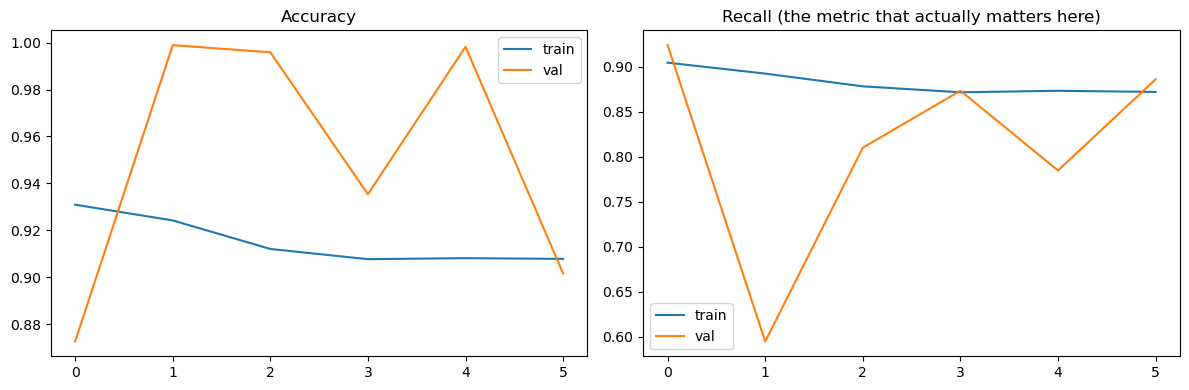

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(history.history['recall'], label='train')
axes[1].plot(history.history['val_recall'], label='val')
axes[1].set_title('Recall (the metric that actually matters here)'); axes[1].legend()
plt.tight_layout()
plt.show()

In [37]:
# Training accuracy
y_pred_train = np.where(model.predict(X_train_res) > 0.5, 1, 0)
train_acc = accuracy_score(y_train_res, y_pred_train)

# Validation accuracy
y_pred_val = np.where(model.predict(X_val_t) > 0.5, 1, 0)
val_acc = accuracy_score(y_val, y_pred_val)

# Test accuracy
y_pred_test = np.where(model.predict(X_test_t) > 0.5, 1, 0)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")

11373/11373 ━━━━━━━━━━━━━━━━━━━━ 7s 581us/step
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 1s 769us/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 541us/step
Train Accuracy      : 0.9216
Validation Accuracy : 0.8727
Test Accuracy       : 0.8721


In [38]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.87      0.93     56864
           1       0.01      0.96      0.03        98

    accuracy                           0.87     56962
   macro avg       0.51      0.92      0.48     56962
weighted avg       1.00      0.87      0.93     56962



In [39]:
import pickle

with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

model.save('model.keras')
print("Saved preprocessor.pkl and model.keras")

Saved preprocessor.pkl and model.keras
